In [1]:
#!pip install git+https://github.com/alan-turing-institute/SigNet.git
# !pip install --upgrade matplotlib
#!python -m pip install basemap

In [2]:
!pip install 'scipy>=1.8'

In [3]:
%matplotlib inline
from WSBM import *
from copy import deepcopy
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, normalized_mutual_info_score, accuracy_score
from signet.cluster import Cluster
from sklearn.manifold import spectral_embedding,SpectralEmbedding
import scipy.sparse as ss
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import pairwise_kernels
import sys
sys.path.insert(1, '/home/felipe/Documentos/CSBM-main/Python')
import functions as CSBM
from divergences import *
import dataframe_image as dfi
import os
import warnings
from BregmanClustering import models
import subprocess
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
method = 'hard'
initialization="akaike"
path = "/home/felipe/Documentos/BregmanBenchmark/data/Dreveton_benchmark/"

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Feb 17 17:08:00 2023

@author: maximilien
"""
from tqdm import tqdm

SIZE_TITLE = 24
SIZE_LABELS = 24
SIZE_TICKS = 18
SIZE_LEGEND = 18

def unitRootCoordinates( d = 2, r=1 ):
    coordinates = []
    for k in range( d ):
        coordinates.append( [ r*np.cos(2*k*np.pi / d ), r*np.sin( 2*k*np.pi / d ) ])
    return coordinates

def generateData( sizes, p, mu ):
    n = sum( sizes )
    n_clusters = len( sizes )
    d = len( mu[0] )
    
    labels_true = np.zeros( n )
    #TODO: implement even if K > 2
    for i in range( n// n_clusters, n ):
        labels_true[ i ] = 1
    labels_true = labels_true.astype( int )

    G = nx.stochastic_block_model( sizes, p )
    X = nx.adjacency_matrix( G ).todense()
    
    Y = np.zeros( ( n,d ) )
    for i in range( n ):
        Y[i,:] = np.random.normal( loc = mu[ labels_true[i] - 1 ] )
    return X, Y, labels_true


def plotting( x, curves, labels, xticks,
             curves_std = None,
             legendTitle = '', figTitle = '',
             xlabel = 'a', ylabel = 'ARI',
             saveFig = False, fileName = 'fig.eps'):
    
    if len( curves ) != len( labels ):
        raise TypeError( 'The number of labels is different from the number of curves' )
    
    if curves_std == None:
        for i in range( len( labels) ):
            plt.plot( x, curves[i], label = labels[i])
    else:
        for i in range( len( labels) ):
            plt.errorbar( x, curves[ i ], yerr = curves_std[ i ], linestyle = '-.', label = labels[ i ] )

    
    legend = plt.legend( title = legendTitle, loc=4,  fancybox=True, fontsize= SIZE_LEGEND )
    plt.setp( legend.get_title(),fontsize= SIZE_LEGEND )
    plt.xlabel( xlabel, fontsize = SIZE_LABELS )
    plt.ylabel( ylabel, fontsize = SIZE_LABELS )
    plt.xticks( xticks, fontsize = SIZE_TICKS )
    plt.yticks( fontsize = SIZE_TICKS )
    plt.title( figTitle, fontsize = SIZE_TITLE )
    if saveFig:
        plt.savefig( fileName, format = 'eps', bbox_inches = 'tight' )

#Somehow some errors message sometimes arises such as 
#RuntimeWarning: divide by zero encountered in log
#But this shouldn be a problem

In [6]:
c = 3
n = 100
N = c*n
delta = 10
d = 2
dim = c*d
P = np.array([[0.8, 0.2, 0.3],[0.2, 0.7, 0.4],[0.3, 0.4, 0.6]])
true_labels = [0]*n + [1]*n + [2]*n

In [23]:
X,Y = BregmanBenchmark(P,[n]*c,1,10,dims=2,weight_variance=0.01,att_variance=0.1,\
                       weight_distribution="logistic",attributes_distribution="logistic").generate_benchmark_WSBM()

In [24]:
X

array([[ 0.  ,  0.98,  1.02, ...,  0.  ,  4.42,  0.  ],
       [ 0.98,  0.  ,  0.  , ...,  0.  ,  0.  ,  0.  ],
       [ 1.02,  0.  ,  0.  , ...,  4.67,  0.  ,  4.7 ],
       ...,
       [ 0.  ,  0.  ,  4.67, ...,  0.  ,  0.  , 10.05],
       [ 4.42,  0.  ,  0.  , ...,  0.  ,  0.  ,  9.96],
       [ 0.  ,  0.  ,  4.7 , ..., 10.05,  9.96,  0.  ]])

In [ ]:
plt.scatter(Y[:,0],Y[:,1],c=true_labels)

In [17]:
def get_spectral_decomposition(A,k):
    if (A<0).any():
        A = pairwise_kernels(A,metric='rbf')
    U = SpectralEmbedding(n_components=k,affinity="precomputed").fit_transform(A)
    return U
def spectral(A,k):
    U = get_spectral_decomposition(A,k)
    return GaussianMixture(n_components=k).fit_predict(U.real)
pred_labels = spectral(X.copy(),c)
print(adjusted_rand_score(true_labels, pred_labels),normalized_mutual_info_score(true_labels, pred_labels))

1.0 1.0


In [18]:
pred_labels = GaussianMixture(n_components=c).fit_predict(Y.copy())
print(adjusted_rand_score(true_labels, pred_labels),normalized_mutual_info_score(true_labels, pred_labels))

1.0 1.0


In [19]:
model = models.BregmanNodeAttributeGraphClustering(n_clusters=c,graph_divergence=logistic_loss)
model.fit(X.copy(), Y.copy())
z_pred_both = model.predict(X,Y)
z_pred_att = models.frommembershipMatriceToVector( model.memberships_from_attributes )
z_pred_graph = models.frommembershipMatriceToVector( model.memberships_from_graph )

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fd88122f670>
Traceback (most recent call last):
  File "/home/felipe/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/felipe/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/felipe/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/felipe/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.mat

graph :  0.30790945172820483
attributes 0.0007364411991464671
Initialisation chosen from the graph
number of iterations :  25


In [21]:
print(adjusted_rand_score(true_labels, z_pred_both),normalized_mutual_info_score(true_labels, z_pred_both))

0.0 0.0


  0%|                                                     | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_16479/4042594093.py:33: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  X = nx.adjacency_matrix( G ).todense()
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _ThreadpoolIn

graph :  0.0034332436251380462
attributes 0.001008667358627425
Initialisation chosen from the attributes


/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f4ced19a4c0>
Traceback (most recent call last):
  File "/home/felipe/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from

graph :  0.0028491588886509185
attributes 0.0010081564268143532
Initialisation chosen from the attributes
number of iterations :  25
[1] TRUE


/home/felipe/anaconda3/lib/R/library/reticulate/config/config.py:5: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

/tmp/ipykernel_16479/4042594093.py:33: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  X = nx.adjacency_matrix( G ).todense()
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matri

...

/home/felipe/anaconda3/lib/R/library/reticulate/config/config.py:5: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

/tmp/ipykernel_16479/4042594093.py:33: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  X = nx.adjacency_matrix( G ).todense()
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matri

graph :  0.016008562265363045
attributes 0.0009598264272653132
Initialisation chosen from the graph


/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/home/felipe/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f4ced525820>
Traceback (most recent call last):
  File "/home/felipe/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from

graph :  0.016008562265363045
attributes 0.0009598264272653132
Initialisation chosen from the graph
number of iterations :  25
[1] TRUE


/home/felipe/anaconda3/lib/R/library/reticulate/config/config.py:5: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

100%|████████████████████████████████████████████| 6/6 [10:47<00:00, 107.92s/it]
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


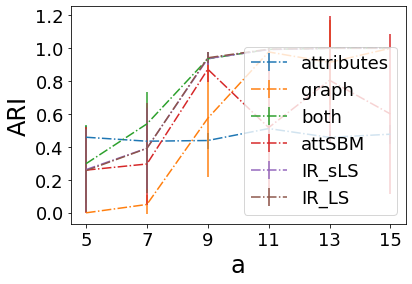

In [16]:
n_average = 10

#varying = 'attributes'
varying = 'graph'

n = 300
n_clusters = 2
d = 1
sizes = [ n // n_clusters ]*np.ones( n_clusters, dtype = int )

b = 5
pout = b * np.log( n ) / n

a_range = [ 5,7,9,11,13,15 ]
r_range = [ 0,1,2,3,4,5 ]

aris_attributes_mean = [ ]
aris_graph_mean = [ ]
aris_both_mean = [ ]
aris_attSBM_mean = [ ]
aris_IR_sLS_mean = [ ]
aris_IR_LS_mean = [ ]

aris_attributes_std = [ ]
aris_graph_std = [ ]
aris_both_std = [ ]
aris_attSBM_std = [ ]
aris_IR_sLS_std = [ ]
aris_IR_LS_std = [ ]

if varying == 'graph':
    loop = tqdm( range( len( a_range ) ) )
else:
    loop = tqdm( range( len( r_range ) ) )

for dummy in loop:
    if varying == 'graph':
        a = a_range[ dummy ]
        r = 1
    elif varying == 'attributes':
        a = 8
        r = r_range[ dummy ]
    mu = [ [r], [-r] ]
    #mu = unitRootCoordinates( d=2, r=r )
    
    pin = a * np.log( n ) / n
    p = (pin- pout) * np.eye( n_clusters ) + pout * np.ones( (n_clusters, n_clusters) )
    
    aris_attributes = [ ]
    aris_graph = [ ]
    aris_both = [ ]
    aris_attSBM = []
    aris_IR_sLS  = []
    aris_IR_LS = []

    path_ = path+f"a/{a}/r/{r}/"
    if not os.path.exists(path_):
        os.makedirs(path_)
    
    for trial in range( n_average ):
        ( X, Y, z_true ) = generateData( sizes, p, mu )
        model = models.BregmanNodeAttributeGraphClustering( n_clusters = n_clusters)
        ## For comparison purposes, the initialization is the same for IR-sLS, IR-LS and ours    
        model.initialize( X, Y )
        model.assignInitialLabels( X, Y )
        z_init = model.predicted_memberships.copy()
        
        with open(f'{path_}att_{trial}.npy', 'wb') as g:
            np.save(g, Y)
        with open(f'{path_}net_{trial}.npy', 'wb') as g:
            np.save(g, X)
        with open(f'{path_}z_init_{trial}.npy', 'wb') as g:
            np.save(g, CSBM.convertZ(z_init)+1)
        
        model.fit( X, Y )
        z_pred_both = model.predict( X, Y )
        z_pred_graph = models.frommembershipMatriceToVector( model.memberships_from_graph )
        z_pred_attributes = models.frommembershipMatriceToVector( model.memberships_from_attributes )
        IR_sLS_pred = CSBM.iter_csbm(X,Y,z_init,n_clusters)
        IR_LS_pred = CSBM.iter_csbm2(X,Y,z_init,n_clusters)
        
        subprocess.call(["Rscript" ,"--vanilla","/home/felipe/Documentos/BregmanBenchmark/BregmanClustering/run_AttSBM.r",\
                        f'{path_}att_{trial}.npy',\
                        f'{path_}net_{trial}.npy',\
                        f'{path_}z_init_{trial}.npy'])
        
        attSBMPred = np.load("predict.npy")
        
        aris_attributes.append( adjusted_rand_score( z_true, z_pred_attributes ) )
        aris_graph.append( adjusted_rand_score( z_true, z_pred_graph ) )
        aris_both.append( adjusted_rand_score( z_true, z_pred_both ) )
        aris_attSBM.append( adjusted_rand_score( z_true, attSBMPred ) )
        aris_IR_sLS.append( adjusted_rand_score( z_true, IR_sLS_pred ) )
        aris_IR_LS.append( adjusted_rand_score( z_true, IR_LS_pred ) )
        
    aris_attributes_mean.append( np.mean( aris_attributes ) )
    aris_graph_mean.append( np.mean( aris_graph ) )
    aris_both_mean.append( np.mean( aris_both ) )
    aris_attSBM_mean.append( np.mean( aris_attSBM ) )
    aris_IR_sLS_mean.append( np.mean( aris_IR_sLS ) )
    aris_IR_LS_mean.append( np.mean( aris_IR_LS ) )
    
    aris_attributes_std.append( np.std( aris_attributes ) )
    aris_graph_std.append( np.std( aris_graph ) )
    aris_both_std.append( np.std( aris_both ) )
    aris_attSBM_std.append( np.std( aris_attSBM ) )
    aris_IR_sLS_std.append( np.std( aris_IR_sLS ) )
    aris_IR_LS_std.append( np.std( aris_IR_LS ) )

curves = [ aris_attributes_mean, aris_graph_mean, aris_both_mean , aris_attSBM_mean, aris_IR_sLS_mean, aris_IR_LS_mean]
curves_std = [ aris_attributes_std, aris_graph_std, aris_both_std , aris_attSBM_std, aris_IR_sLS_std, aris_IR_LS_std]

labels = [ 'attributes', 'graph', 'both' , 'attSBM', 'IR_sLS', 'IR_LS']
saveFig = True
if varying == 'graph':    
    fileName = 'N_' + str(n) + '_K_' + str(n_clusters) + '_b_' + str(b) + '_r_' + str(r) +  '_nAverage' + str(n_average) + '.eps'
    plotting( a_range, curves, labels, curves_std = curves_std, xticks = a_range, xlabel = 'a', saveFig = saveFig, fileName = fileName )

elif varying == 'attributes':
    fileName = 'N_' + str(n) + '_K_' + str(n_clusters) + '_a_' + str(a) + '_b_' + str(b) +  '_nAverage_' + str(n_average) + '.eps'
    plotting( r_range, curves, labels, curves_std = curves_std, xticks = r_range, xlabel = 'r', saveFig = saveFig, fileName = fileName )